In this file we are going to Implement an example of the subgraph having the seperate state form the other parent graph

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class Child(TypedDict):
    question: str
    answer: str
    summary: str

class Parent(TypedDict):
    query: str
    explanation: str #it will be implemented in seperate graph to implement subgraph 
    final_response: str


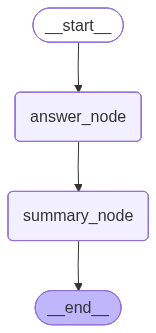

In [3]:

def answer_node(state: Child):
    print(state['question'])
    answer = "Answer: imagine answer is 6 + 6 = 12"
    return {
        "answer": answer
    }
def summary_node(state: Child):
    print(state['answer'])
    summary = "Summary: 6 + 6 = 12"
    return{
        "summary": summary
    }
graph = StateGraph(Child)
graph.add_node(answer_node, 'answer_node')
graph.add_node(summary_node, 'summary_node')
graph.add_edge(START, 'answer_node')
graph.add_edge('answer_node', 'summary_node')
graph.add_edge('summary_node', END)

subgraph = graph.compile()
subgraph

In [8]:
def sub_graph(parent: Parent):
    child_initial_state = {
        "question" : parent['query']
    }

    subgraph.invoke(child_initial_state)
    return {}

In [9]:
def explain_node(state : Parent)-> dict:
    print(state['query'])
    explanation = 'As the question is 6 + 6 in math if we count it gets equal to 12'
    return{
        "explanation":explanation
    }

def final_node(state : Parent)-> dict:
    print(state['explanation'])
    final = 'Explanation: This is a simple mathematics question .As the question is 6 + 6 in math if we count it gets equal to 12'
    print(final)
    return{
        "final_response":final
    }

In [10]:
graph2 = StateGraph(Parent)
graph2.add_node('subgraph', sub_graph)
graph2.add_node('explain_node', explain_node)
graph2.add_node('final_node', final_node)
graph2.add_edge(START, 'subgraph')
graph2.add_edge(START, 'explain_node')
graph2.add_edge('subgraph', END)
graph2.add_edge('explain_node', 'final_node')
graph2.add_edge('final_node', END)
big_graph = graph2.compile()
big_graph

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 400.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`